In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

In [4]:
print(train.shape)


(198000, 15)


In [5]:
print(train.head())


                       created_date  post_id  emoticon_1  emoticon_2  \
0  2024-01-18 08:43:57.397508+00:00       73           0           0   
1  2024-03-24 21:43:11.490017+00:00       39           0           0   
2  2024-04-24 20:32:17.014931+00:00       31           0           1   
3  2023-05-28 22:00:14.214527+00:00       39           0           0   
4  2023-09-09 23:12:05.689498+00:00       39           0           0   

   emoticon_3  upvote  downvote  if_1  if_2 race religion gender  disability  \
0           0       0         1     0    10  NaN      NaN    NaN       False   
1           0       6         0     0     4  NaN      NaN    NaN       False   
2           1       0         0     0    10  NaN      NaN    NaN       False   
3           0       5         0     0    10  NaN      NaN    NaN       False   
4           0       0         0     0    10  NaN      NaN    NaN       False   

                                             comment  label  
0  She might be a bright

In [6]:
print(train.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None


In [7]:
print(train.describe())

             post_id     emoticon_1     emoticon_2     emoticon_3  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean       68.447429       0.279768       0.048338       0.121071   
std        27.948390       1.023234       0.258477       0.481013   
min        20.000000       0.000000       0.000000       0.000000   
25%        39.000000       0.000000       0.000000       0.000000   
50%        72.000000       0.000000       0.000000       0.000000   
75%        72.000000       0.000000       0.000000       0.000000   
max       129.000000      47.000000      11.000000      17.000000   

              upvote       downvote           if_1           if_2  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean        2.607975       0.666394       1.906152       7.956212   
std         5.054763       2.044335      25.635752      14.839464   
min         0.000000       0.000000       0.000000       3.000000   
25%         0.000000       0.0000

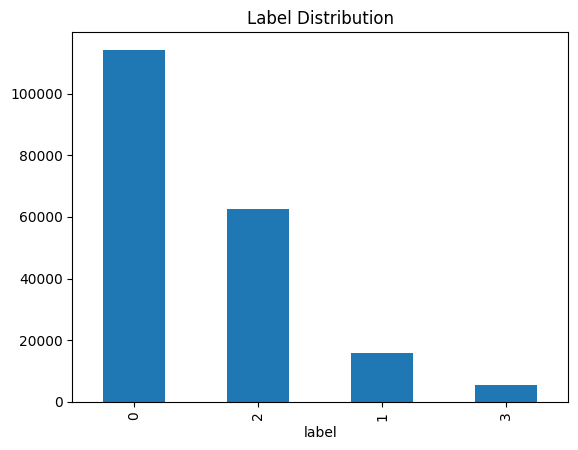

In [8]:
train['label'].value_counts().plot(kind='bar')
plt.title('Label Distribution')
plt.show()

In [9]:
categorical_cols = ['race', 'religion', 'gender', 'disability']
numericals_cols = ['upvote','downvote','emoticon_1','emoticon_2','emoticon_3','if_1','if_2']

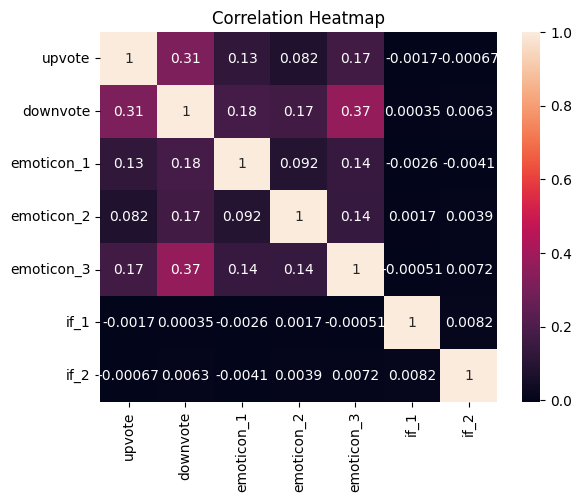

In [10]:
corr = train[numericals_cols].corr()
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

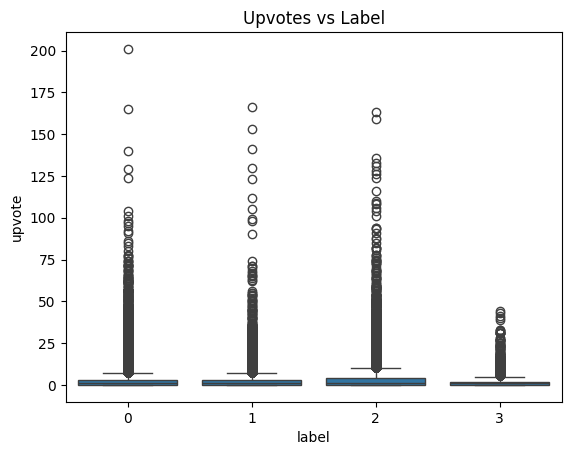

In [11]:
plt.figure()
sns.boxplot(x='label', y='upvote', data=train)
plt.title('Upvotes vs Label')
plt.show()


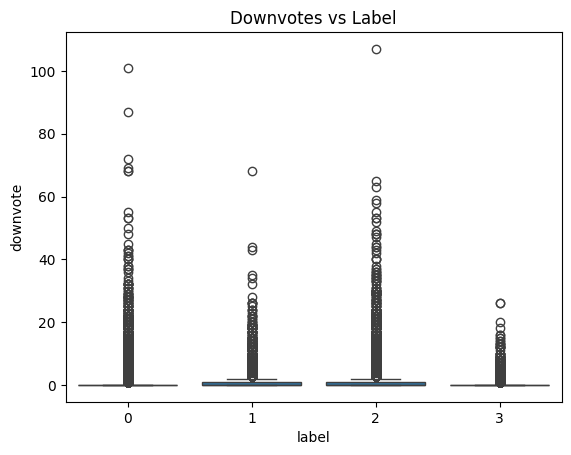

In [12]:
plt.figure()
sns.boxplot(x='label', y='downvote', data=train)
plt.title('Downvotes vs Label')
plt.show()


In [13]:
train['vote_diff'] = train['upvote'] - train['downvote']
train['vote_ratio'] = train['upvote'] / (train['downvote'] + 1)
train[['vote_diff', 'vote_ratio']].describe()

,vote_diff,vote_ratio
count,198000.000000,198000.000000
mean,1.941581,1.801146
std,4.819638,3.359204
min,-81.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,3.000000,2.000000
max,161.000000,159.000000


In [14]:
train.isnull().sum()


created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
vote_diff            0
vote_ratio           0
dtype: int64

In [15]:
test.isnull().sum()

created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64

In [16]:
y=['race','religion','gender','comment']
for x in y:
    train[x] = train[x].fillna("none")
    test[x] = test[x].fillna("none")

In [17]:
test.isnull().sum()

created_date    0
post_id         0
emoticon_1      0
emoticon_2      0
emoticon_3      0
upvote          0
downvote        0
if_1            0
if_2            0
race            0
religion        0
gender          0
disability      0
comment         0
dtype: int64

In [18]:
train.isnull().sum()

created_date    0
post_id         0
emoticon_1      0
emoticon_2      0
emoticon_3      0
upvote          0
downvote        0
if_1            0
if_2            0
race            0
religion        0
gender          0
disability      0
comment         0
label           0
vote_diff       0
vote_ratio      0
dtype: int64

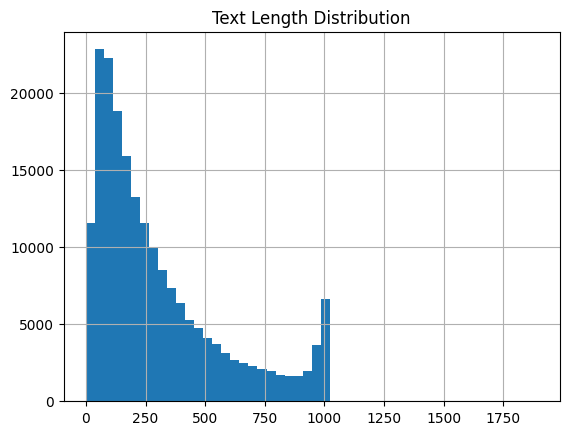

In [19]:
train['text_length'] = train['comment'].astype(str).apply(len)
plt.figure()
train['text_length'].hist(bins=50)
plt.title("Text Length Distribution")
plt.show()

In [20]:
tfidf = TfidfVectorizer()
X_train = tfidf.fit_transform(train["comment"])
X_test = tfidf.transform(test["comment"])
model1=LinearSVC()
y=train["label"]
model1.fit(X_train,y)
pred=model1.predict(X_train)
print("for linearSVC ",round(accuracy_score(y, pred),3))

for linearSVC  0.912


In [21]:
modelx=LogisticRegression()
y=train["label"]
modelx.fit(X_train,y)
pred=modelx.predict(X_train)
print("for logisticRegression ",round(accuracy_score(y, pred),3))

for logisticRegression  0.822


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
modely=SGDClassifier()
y=train["label"]
modely.fit(X_train,y)
pred=modely.predict(X_train)
print("for SGDClassifier",round(accuracy_score(y, pred),3))

for SGDClassifier 0.736


In [23]:
tfidf_for_word = TfidfVectorizer(
    max_features=80000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

tfidf_for_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,6),
    min_df=2,
    max_features=30000
)

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
    ('word', tfidf_for_word, 'comment'),
('char', tfidf_for_char, 'comment'),
    ('cat', OneHotEncoder(handle_unknown='ignore'),categorical_cols),
        ('num',StandardScaler(with_mean=False),numericals_cols)
    ]
)

In [25]:
pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('model', SGDClassifier(
        loss='log_loss',
        penalty='elasticnet',
        alpha=0.000015,
        l1_ratio=0.15,
        max_iter=5000,
        tol=1e-5,
        class_weight='balanced',
        random_state=42
    ))
])
X=train.drop('label', axis=1)
y=train['label']
pipe.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('word',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=80000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  sublinear_tf=True),
                                                  'comment'),
                                                 ('char',
                                                  TfidfVectorizer(analyzer='char',
                                                                  max_features=30000,
                                                                  min_df=2,
                                                                  ngram_range=(3,
                                                                               6)),
                                                  'comment'),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['race', 'religion', 'gender',
                                                   'disability']),
                                                 ('num',
                                                  StandardScaler(with_mean=False),
                                                  ['upvote', 'downvote',
                                                   'emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'if_1',
                                                   'if_2'])])),
                ('model',
                 SGDClassifier(alpha=1.5e-05, class_weight='balanced',
                               loss='log_loss', max_iter=5000,
                               penalty='elasticnet', random_state=42,
                               tol=1e-05))])

In [26]:
pre_label=pipe.predict(test)

In [27]:

print(pre_label[:5])

[2 2 0 2 2]


In [28]:
submission = pd.DataFrame({"ID":range(1, len(test) + 1),"label": pre_label})


In [29]:
submission.to_csv("submission.csv", index=False)

In [30]:
print("Shape of training data:", train.shape)

Shape of training data: (198000, 18)


In [31]:
print("Test dataset shape:", test.shape)

Test dataset shape: (102000, 14)


In [32]:
print(train.select_dtypes(include=['object']).shape[1])
print(train.select_dtypes(include=['int64', 'float64']).shape[1])
    

5
12


In [33]:
train.dtypes


created_date     object
post_id           int64
emoticon_1        int64
emoticon_2        int64
emoticon_3        int64
upvote            int64
downvote          int64
if_1              int64
if_2              int64
race             object
religion         object
gender           object
disability         bool
comment          object
label             int64
vote_diff         int64
vote_ratio      float64
text_length       int64
dtype: object

In [34]:
train['label'].nunique()


4

In [35]:
train['label'].value_counts(normalize=True) * 100


label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64

In [36]:
train['upvote'].median()


1.0